In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIGURATION
# =========================

# Path to your CSV file (change this to your actual file path if needed)
CSV_PATH   = r'D:\Python-Foundation\Dataset\GBPUSD2000_2018.csv'

# Horizons (in days) to look into the future
# Example: 1, 5, 10, 20 days future returns
HORIZONS   = [1, 5, 10, 20]

# Main horizon you care about most (used later to judge which strategy is better)
H_PRIMARY  = 5

# DEADZONE: if > 0, small returns between -DEADZONE and +DEADZONE are labeled as "0" (neutral)
# If 0.0 → strictly up or down (no neutral)
DEADZONE   = 0.0

# Moving Average (MA) crossover parameters
MA_FAST   = 28        # fast moving average window
MA_SLOW   = 260       # slow moving average window
X_THRESH  = 0.05      # threshold on (MA_FAST - MA_SLOW), to avoid tiny/noisy crossovers

# Bollinger Band parameters
BB_WINDOW = 21        # rolling window size (in bars) for mean/std
BB_STD    = 2         # how many std deviations for upper/lower bands

# Date filter (limit your backtest period)
START = '2010-01-01'
END   = '2018-12-31'

# Make pandas print floats nicely
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

In [4]:
# =========================
# LOAD & PREPARE DATA
# =========================

# Load the CSV file
# Assumes first column is Date and contains date strings
df = pd.read_csv(
    CSV_PATH,
    header=0,         # first row is header
    index_col=0,      # first column becomes the index (Date)
    parse_dates=True  # parse index as datetime
)

# Ensure 'Close' is numeric (convert invalid strings to NaN)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Sort by date (just to be safe)
df = df.sort_index()

# Filter to the desired period
df = df.loc[START:END].copy()

print("Data after filtering:")
print(df.head())
print(df.tail())

Data after filtering:
               Open     High      Low    Close  Adj Close   Volume  10MA  30MA
Date                                                                          
2010-01-01 1.618202 1.618202 1.613111 1.613294   1.613294 0.000000   NaN   NaN
2010-01-04 1.613294 1.623904 1.606503 1.611370   1.611370 0.000000   NaN   NaN
2010-01-05 1.611863 1.615587 1.597010 1.599079   1.599079 0.000000   NaN   NaN
2010-01-06 1.599360 1.606323 1.594388 1.602384   1.602384 0.000000   NaN   NaN
2010-01-07 1.602205 1.605858 1.590078 1.593397   1.593397 0.000000   NaN   NaN
               Open     High      Low    Close  Adj Close   Volume  10MA  30MA
Date                                                                          
2017-12-26 1.337489 1.337972 1.334917 1.337614   1.337614 0.000000   NaN   NaN
2017-12-27 1.337381 1.343183 1.337041 1.337471   1.337471 0.000000   NaN   NaN
2017-12-28 1.340267 1.345714 1.339926 1.340393   1.340393 0.000000   NaN   NaN
2017-12-29 1.344267 1.354151 1

In [5]:
# =========================
# BUILD INDICATORS & SIGNALS
# =========================

# ---------- Moving Average Crossover Strategy ----------
# Calculate fast and slow moving averages
df['ma_fast'] = df['Close'].rolling(MA_FAST).mean()
df['ma_slow'] = df['Close'].rolling(MA_SLOW).mean()

# Difference between the two MAs
df['ma_diff'] = df['ma_fast'] - df['ma_slow']

# Generate MA signals:
# +1  -> Buy  (uptrend)
# -1  -> Sell (downtrend)
#  0  -> Hold (no clear signal or tiny diff)
df['sig_ma'] = np.where(
    df['ma_diff'] > X_THRESH,  1,      # strongly above -> buy
    np.where(
        df['ma_diff'] < -X_THRESH, -1, # strongly below -> sell
        0                              # in between -> hold
    )
)

# ---------- Bollinger Bands Strategy ----------
# Rolling mean and std dev for Bollinger Bands
df['bb_mid']  = df['Close'].rolling(BB_WINDOW).mean()
df['bb_std']  = df['Close'].rolling(BB_WINDOW).std()
df['bb_high'] = df['bb_mid'] + BB_STD * df['bb_std']
df['bb_low']  = df['bb_mid'] - BB_STD * df['bb_std']

# Bollinger "cross back inside" logic:
# Buy  when price was below lower band and comes back up into the band
# Sell when price was above upper band and comes back down into the band
buy_cross  = (df['Close'].shift(1) < df['bb_low'].shift(1))  & (df['Close'] >= df['bb_low'])
sell_cross = (df['Close'].shift(1) > df['bb_high'].shift(1)) & (df['Close'] <= df['bb_high'])

# Initialize Bollinger signal column
df['sig_bb'] = 0
df.loc[buy_cross,  'sig_bb'] = 1   # Buy signals
df.loc[sell_cross, 'sig_bb'] = -1  # Sell signals

# Drop initial rows where indicators are NaN (because of rolling windows)
df = df.dropna(subset=['ma_fast', 'ma_slow', 'bb_high', 'bb_low']).copy()

print("Data with indicators & signals:")
print(df[['Close', 'ma_fast', 'ma_slow', 'bb_mid', 'bb_high', 'bb_low', 'sig_ma', 'sig_bb']].head())

Data with indicators & signals:
              Close  ma_fast  ma_slow   bb_mid  bb_high   bb_low  sig_ma  \
Date                                                                       
2010-12-30 1.550195 1.563173 1.545893 1.560346 1.591817 1.528874       0   
2010-12-31 1.543710 1.561353 1.545625 1.559520 1.591814 1.527227       0   
2011-01-03 1.557244 1.560522 1.545417 1.559433 1.591741 1.527124       0   
2011-01-04 1.548971 1.559450 1.545224 1.558108 1.589700 1.526515       0   
2011-01-05 1.559795 1.558872 1.545060 1.557580 1.588644 1.526517       0   

            sig_bb  
Date                
2010-12-30       0  
2010-12-31       0  
2011-01-03       0  
2011-01-04       0  
2011-01-05       0  


In [6]:
# =========================
# FUTURE RETURNS & LABELS (GROUND TRUTH)
# =========================

for h in HORIZONS:
    # Column names for future return and label
    fcol = f'future_ret_{h}d'
    lcol = f'label_{h}d'
    
    # Future return over horizon h:
    # (Price_{t+h} / Price_t) - 1
    df[fcol] = df['Close'].shift(-h) / df['Close'] - 1.0
    
    # Convert future returns to directional labels (+1, -1, maybe 0)
    if DEADZONE > 0:
        # If DEADZONE > 0, small moves are "0" (no clear direction)
        df[lcol] = np.where(
            df[fcol] >  DEADZONE,  1,        # clearly up
            np.where(
                df[fcol] < -DEADZONE, -1,    # clearly down
                0                            # in between -> neutral/flat
            )
        )
    else:
        # If DEADZONE == 0: strict up vs down (binary labels)
        df[lcol] = np.where(df[fcol] > 0, 1, -1)

print("Data with future returns & labels (example for 5 days):")
print(df[[f'future_ret_{H_PRIMARY}d', f'label_{H_PRIMARY}d']].head(10))

Data with future returns & labels (example for 5 days):
            future_ret_5d  label_5d
Date                               
2010-12-30       0.000652         1
2010-12-31       0.000897         1
2011-01-03      -0.002082        -1
2011-01-04       0.006469         1
2011-01-05       0.000640         1
2011-01-06       0.015293         1
2011-01-07       0.025364         1
2011-01-10       0.021963         1
2011-01-11       0.019891         1
2011-01-12       0.022747         1


In [7]:
# =========================
# EVALUATION: HOW RIGHT/WRONG + CONSEQUENCES
# =========================

def evaluate_strategy(df, sig_col, horizons):
    """
    Evaluate a strategy defined by `sig_col` (e.g., 'sig_ma' or 'sig_bb').
    
    For each horizon h:
      - Compute accuracy (hit rate)
      - Separate Buy / Sell / Hold behavior
      - Compute average return:
            - when the decision is correct
            - when the decision is wrong
    """
    rows = []
    total_rows = len(df)
    
    for h in horizons:
        # Column names for truth (labels) and future returns
        lcol = f'label_{h}d'
        rcol = f'future_ret_{h}d'
        
        # Only keep rows where:
        #  - label is available (not NaN)
        #  - signal is available (not NaN)
        sub = df[[sig_col, lcol, rcol]].dropna().copy()
        n_all = len(sub)
        
        if n_all == 0:
            # No data for this horizon
            rows.append({
                'horizon_days': h,
                'total_points': 0,
                'coverage_%': np.nan,
                'overall_hit_rate_%': np.nan,
                'avg_ret_all': np.nan,
                'avg_ret_when_right': np.nan,
                'avg_ret_when_wrong': np.nan,
                'buy_hit_rate_%': np.nan,
                'sell_hit_rate_%': np.nan,
                'hold_hit_rate_%': np.nan,
                'avg_ret_buy': np.nan,
                'avg_ret_sell': np.nan,
                'avg_ret_hold': np.nan,
            })
            continue
        
        # ---------- Overall correctness ----------
        # Correct if signal (decision) equals label (ground truth)
        correct_mask = (sub[sig_col] == sub[lcol])
        hit_rate = correct_mask.mean()  # fraction of correct decisions
        
        # Returns depending on correctness
        ret_all   = sub[rcol]
        ret_right = sub.loc[correct_mask, rcol]
        ret_wrong = sub.loc[~correct_mask, rcol]
        
        avg_ret_all   = ret_all.mean()
        avg_ret_right = ret_right.mean() if len(ret_right) > 0 else np.nan
        avg_ret_wrong = ret_wrong.mean() if len(ret_wrong) > 0 else np.nan
        
        # ---------- Per decision type: Buy / Sell / Hold ----------
        buys  = sub[sub[sig_col] == 1]
        sells = sub[sub[sig_col] == -1]
        holds = sub[sub[sig_col] == 0]
        
        # Hit rates by action (when that action is taken)
        buy_hit  = (buys[sig_col]  == buys[lcol]).mean()  if len(buys)  > 0 else np.nan
        sell_hit = (sells[sig_col] == sells[lcol]).mean() if len(sells) > 0 else np.nan
        hold_hit = (holds[sig_col] == holds[lcol]).mean() if len(holds) > 0 else np.nan
        
        # Average future return when you Buy / Sell / Hold
        avg_ret_buy  = buys[rcol].mean()  if len(buys)  > 0 else np.nan
        avg_ret_sell = sells[rcol].mean() if len(sells) > 0 else np.nan
        avg_ret_hold = holds[rcol].mean() if len(holds) > 0 else np.nan
        
        rows.append({
            'horizon_days': h,
            'total_points': n_all,
            'coverage_%': round(100 * n_all / total_rows, 2),
            
            # Overall correctness
            'overall_hit_rate_%': round(100 * hit_rate, 2),
            'avg_ret_all': avg_ret_all,
            'avg_ret_when_right': avg_ret_right,
            'avg_ret_when_wrong': avg_ret_wrong,
            
            # Action-specific accuracy
            'buy_hit_rate_%': round(100 * buy_hit, 2)  if not np.isnan(buy_hit)  else np.nan,
            'sell_hit_rate_%': round(100 * sell_hit, 2) if not np.isnan(sell_hit) else np.nan,
            'hold_hit_rate_%': round(100 * hold_hit, 2) if not np.isnan(hold_hit) else np.nan,
            
            # Action-specific returns
            'avg_ret_buy':  avg_ret_buy,
            'avg_ret_sell': avg_ret_sell,
            'avg_ret_hold': avg_ret_hold,
        })
    
    return pd.DataFrame(rows)

In [8]:
# =========================
# RUN EVALUATION FOR BOTH STRATEGIES
# =========================

res_ma = evaluate_strategy(df, 'sig_ma', HORIZONS)
res_bb = evaluate_strategy(df, 'sig_bb', HORIZONS)

print("=== Detailed Metrics — Moving Average Strategy ===")
print(res_ma)
print("\n=== Detailed Metrics — Bollinger Strategy ===")
print(res_bb)

# Make a simple comparison at the primary horizon
row_ma = res_ma[res_ma['horizon_days'] == H_PRIMARY].iloc[0]
row_bb = res_bb[res_bb['horizon_days'] == H_PRIMARY].iloc[0]

print(f"\n=== Comparison at {H_PRIMARY}-day horizon ===")
print("Moving Average:")
print(row_ma)
print("\nBollinger:")
print(row_bb)

=== Detailed Metrics — Moving Average Strategy ===
   horizon_days  total_points  coverage_%  overall_hit_rate_%  avg_ret_all  \
0             1          1182   99.920000           22.500000    -0.000139   
1             5          1178   99.580000           21.560000    -0.000685   
2            10          1173   99.150000           21.140000    -0.001403   
3            20          1163   98.310000           20.720000    -0.003200   

   avg_ret_when_right  avg_ret_when_wrong  buy_hit_rate_%  sell_hit_rate_%  \
0           -0.003944            0.000967       47.620000        51.360000   
1           -0.008910            0.001576       45.240000        49.060000   
2           -0.013232            0.001769       38.100000        48.430000   
3           -0.019063            0.000946       40.480000        46.760000   

   hold_hit_rate_%  avg_ret_buy  avg_ret_sell  avg_ret_hold  
0         0.000000    -0.000247     -0.000013     -0.000222  
1         0.000000    -0.001716      0.0000

In [9]:
# =========================
# SIMPLE VERDICT FUNCTION
# =========================

def pick_winner_simple(res_ma, res_bb, h_primary):
    """
    Compare MA vs Bollinger at a chosen horizon.
    Criteria:
      1) Higher overall hit rate
      2) If close, compare avg_ret_all
    """
    row_ma = res_ma[res_ma['horizon_days'] == h_primary].iloc[0]
    row_bb = res_bb[res_bb['horizon_days'] == h_primary].iloc[0]
    
    ma_hit = row_ma['overall_hit_rate_%']
    bb_hit = row_bb['overall_hit_rate_%']
    ma_ret = row_ma['avg_ret_all']
    bb_ret = row_bb['avg_ret_all']
    
    # Start building explanation
    reasons = []
    
    if ma_hit > bb_hit + 0.01:
        winner = "Moving Average"
        reasons.append(f"higher hit rate ({ma_hit:.2f}% vs {bb_hit:.2f}%)")
    elif bb_hit > ma_hit + 0.01:
        winner = "Bollinger"
        reasons.append(f"higher hit rate ({bb_hit:.2f}% vs {ma_hit:.2f}%)")
    else:
        # Hit rates are similar, use average return
        if ma_ret > bb_ret:
            winner = "Moving Average"
            reasons.append(f"similar hit rate but better avg return ({ma_ret:.6f} vs {bb_ret:.6f})")
        elif bb_ret > ma_ret:
            winner = "Bollinger"
            reasons.append(f"similar hit rate but better avg return ({bb_ret:.6f} vs {ma_ret:.6f})")
        else:
            winner = "Tie"
            reasons.append("very similar hit rate and average return")
    
    explanation = "; ".join(reasons)
    return winner, explanation


winner, explanation = pick_winner_simple(res_ma, res_bb, H_PRIMARY)

print(f"\n=== Verdict at {H_PRIMARY}-day horizon ===")
print(f"Winner: {winner}")
print(f"Explanation: {explanation}")


=== Verdict at 5-day horizon ===
Winner: Moving Average
Explanation: higher hit rate (21.56% vs 3.57%)


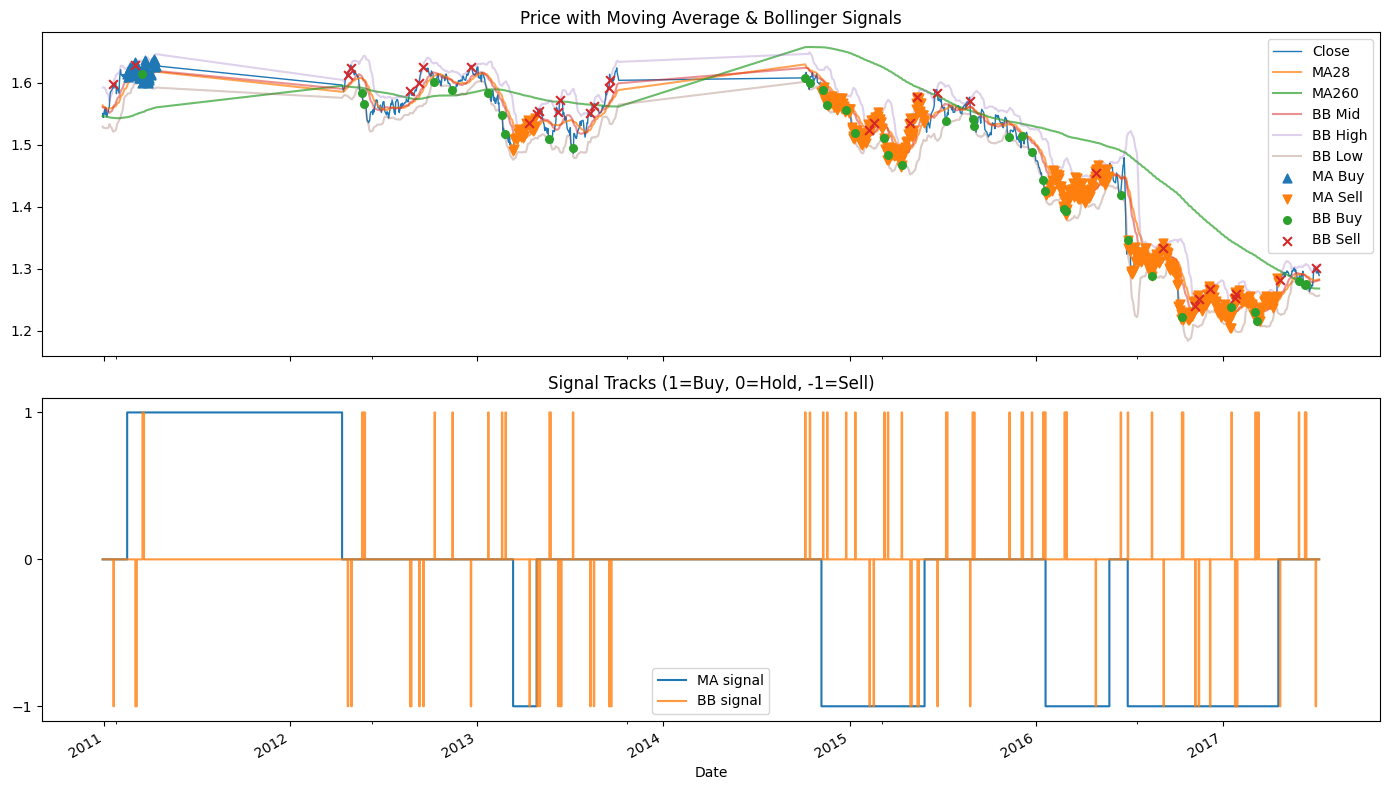

In [10]:
# =========================
# VISUALIZE PRICE + SIGNALS
# =========================

plt.figure(figsize=(14, 8))

# Top subplot: price + MA + Bollinger + signal markers
ax1 = plt.subplot(2, 1, 1)
df['Close'].plot(ax=ax1, label='Close', linewidth=1)

# Plot MA lines
df['ma_fast'].plot(ax=ax1, label=f'MA{MA_FAST}', alpha=0.7)
df['ma_slow'].plot(ax=ax1, label=f'MA{MA_SLOW}', alpha=0.7)

# Plot Bollinger Bands
df['bb_mid'].plot(ax=ax1, label='BB Mid', alpha=0.5)
df['bb_high'].plot(ax=ax1, label='BB High', alpha=0.3)
df['bb_low'].plot(ax=ax1, label='BB Low', alpha=0.3)

# Signal markers (MA)
ma_buys  = df[df['sig_ma'] == 1]
ma_sells = df[df['sig_ma'] == -1]
ax1.scatter(ma_buys.index,  ma_buys['Close'],  marker='^', s=40, label='MA Buy',  zorder=3)
ax1.scatter(ma_sells.index, ma_sells['Close'], marker='v', s=40, label='MA Sell', zorder=3)

# Signal markers (Bollinger)
bb_buys  = df[df['sig_bb'] == 1]
bb_sells = df[df['sig_bb'] == -1]
ax1.scatter(bb_buys.index,  bb_buys['Close'],  marker='o', s=30, label='BB Buy',  zorder=3)
ax1.scatter(bb_sells.index, bb_sells['Close'], marker='x', s=40, label='BB Sell', zorder=3)

ax1.set_title('Price with Moving Average & Bollinger Signals')
ax1.set_xlabel('')
ax1.legend(loc='best')

# Bottom subplot: signal values over time
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
df['sig_ma'].plot(ax=ax2, drawstyle='steps-post', label='MA signal')
df['sig_bb'].plot(ax=ax2, drawstyle='steps-post', label='BB signal', alpha=0.8)
ax2.set_yticks([-1, 0, 1])
ax2.set_title('Signal Tracks (1=Buy, 0=Hold, -1=Sell)')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

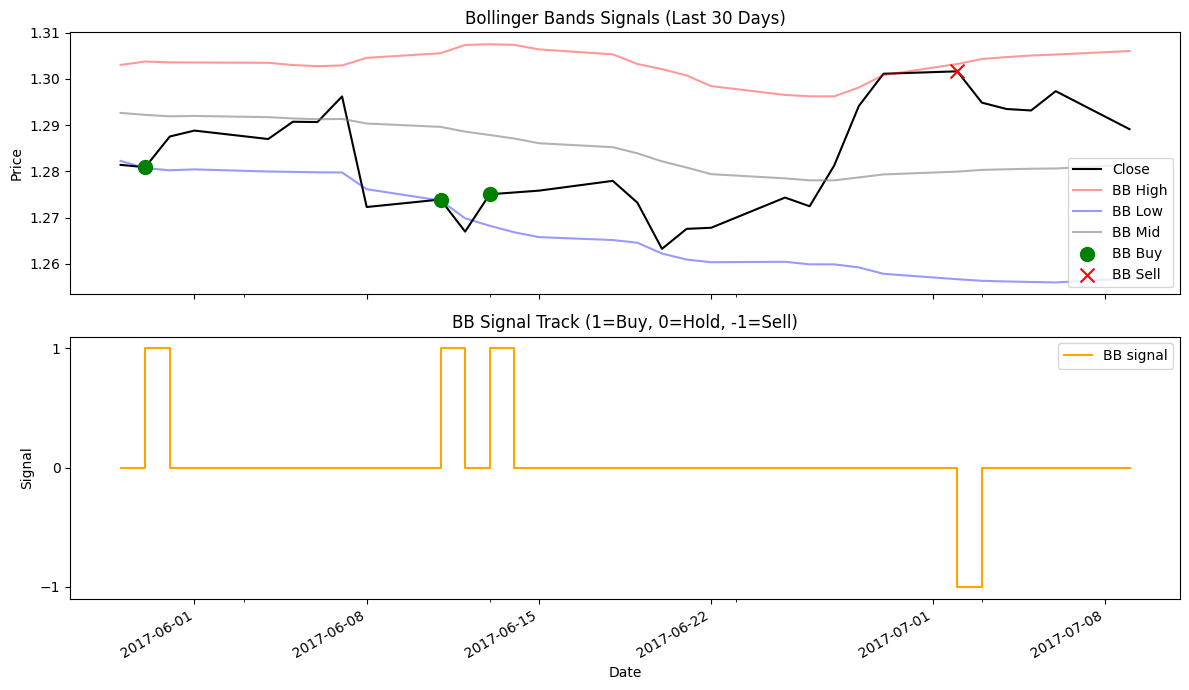

In [26]:
# Plot Bollinger Bands (BB) signals
plt.figure(figsize=(12, 7))

# Top plot: Close price with Bollinger Bands and Buy/Sell signals
ax3 = plt.subplot(2, 1, 1)
df_30['Close'].plot(ax=ax3, label='Close', color='black')
df_30['bb_high'].plot(ax=ax3, alpha=0.4, label='BB High', color='red')
df_30['bb_low'].plot(ax=ax3, alpha=0.4, label='BB Low', color='blue')
df_30['bb_mid'].plot(ax=ax3, alpha=0.6, label='BB Mid', color='grey')

# Markers for BB Buy and Sell signals
bb_buys = df_30[df_30['sig_bb'] == 1]
bb_sells = df_30[df_30['sig_bb'] == -1]
ax3.scatter(bb_buys.index, bb_buys['Close'], marker='o', s=100, label='BB Buy', color='green', zorder=3)
ax3.scatter(bb_sells.index, bb_sells['Close'], marker='x', s=100, label='BB Sell', color='red', zorder=3)

ax3.set_title('Bollinger Bands Signals (Last 30 Days)')
ax3.set_xlabel('Date')
ax3.set_ylabel('Price')
ax3.legend(loc='best')

# Bottom plot: Signal track for BB
ax4 = plt.subplot(2, 1, 2, sharex=ax3)
df_30['sig_bb'].plot(ax=ax4, drawstyle='steps-post', label='BB signal', color='orange')
ax4.set_yticks([-1, 0, 1])
ax4.set_title('BB Signal Track (1=Buy, 0=Hold, -1=Sell)')
ax4.set_ylabel('Signal')
ax4.legend(loc='best')

plt.tight_layout()
plt.show()